# Supplementary 3.4 Data requirements â€” Figure S2
Each selected event subset is refitted and its curves compared with the full-data reference. The fixed event and station selections are in `results/analysis/model_fit/samples/`.

The recorded measurement table below is embedded explicitly so the figure remains available without rerunning thousands of fits. It is a saved experiment, not a fresh optimizer run. Counts show 100/97/100/94/100 available repetitions; the 134-event endpoints are reference values, with 98 LMC MLE fits.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts/models").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from threadpoolctl import threadpool_limits
from scripts.common import core
MODEL_DIR = ROOT / "results/analysis/model_fit"
FIGURES = ROOT / "results/figures"
FIGURES.mkdir(parents=True, exist_ok=True)
payload = core.load_pickle_cross_platform(MODEL_DIR / "models.pkl")

In [2]:
import io
recorded_summary = pd.read_csv(io.StringIO('display_name,model,n_events,n_success,rmse_median,rmse_mean,rmse_std\r\nGH08 semivariogram,gh08,40,100,0.02995,0.03061,0.01066\r\nGH08 semivariogram,gh08,60,97,0.02182,0.02256,0.00763\r\nGH08 semivariogram,gh08,80,100,0.01607,0.01711,0.0062\r\nGH08 semivariogram,gh08,100,94,0.01221,0.01252,0.00509\r\nGH08 semivariogram,gh08,120,100,0.00439,0.00548,0.00353\r\nGH08 semivariogram,gh08,134,1,0.0,0.0,0.0\r\nIOX full semivariogram,iox_full_semivariogram,40,100,0.0261477293262078,0.027545196723602,0.0099425331425437\r\nIOX full semivariogram,iox_full_semivariogram,60,97,0.0192919892738957,0.0204816209875696,0.0071556345473415\r\nIOX full semivariogram,iox_full_semivariogram,80,100,0.0145199495283532,0.0154227434378394,0.0056849316180206\r\nIOX full semivariogram,iox_full_semivariogram,100,94,0.0115422822473414,0.0112950928109559,0.0046819527559118\r\nIOX full semivariogram,iox_full_semivariogram,120,100,0.0039031938741636,0.0049397957757055,0.0032739954781967\r\nIOX full semivariogram,iox_full_semivariogram,134,1,0.0,0.0,0.0\r\nLMC MLE,lmc_block_mle,40,100,0.02215,0.02268,0.00752\r\nLMC MLE,lmc_block_mle,60,97,0.01656,0.01722,0.00628\r\nLMC MLE,lmc_block_mle,80,100,0.0126,0.01291,0.00419\r\nLMC MLE,lmc_block_mle,100,94,0.0095,0.0103,0.00349\r\nLMC MLE,lmc_block_mle,120,100,0.00683,0.00694,0.00246\r\nLMC MLE,lmc_block_mle,134,98,0.00357,0.00244,0.00212\r\nMultivariate Matern semivariogram,multivariate_matern,40,100,0.0317116105711026,0.0363616811579436,0.01398904266945\r\nMultivariate Matern semivariogram,multivariate_matern,60,97,0.0254945888318679,0.0287734657331611,0.010728960831764\r\nMultivariate Matern semivariogram,multivariate_matern,80,100,0.0221056062433696,0.0226391513227174,0.0086924478702025\r\nMultivariate Matern semivariogram,multivariate_matern,100,94,0.0172905295470626,0.0170200322054273,0.0069511488282659\r\nMultivariate Matern semivariogram,multivariate_matern,120,100,0.0084821674862536,0.0098736666195542,0.0059218330854597\r\nMultivariate Matern semivariogram,multivariate_matern,134,1,0.0,0.0,0.0\r\nPCA MLE,pca_mle,40,100,0.02821,0.03236,0.01609\r\nPCA MLE,pca_mle,60,97,0.0196,0.02377,0.01379\r\nPCA MLE,pca_mle,80,100,0.01423,0.0167,0.00871\r\nPCA MLE,pca_mle,100,94,0.01143,0.01331,0.00817\r\nPCA MLE,pca_mle,120,100,0.00545,0.00706,0.00456\r\nPCA MLE,pca_mle,134,1,0.0,0.0,0.0\r\nPCA semivariogram,pca_semivariogram,40,100,0.04235,0.05315,0.03642\r\nPCA semivariogram,pca_semivariogram,60,97,0.03019,0.03512,0.0244\r\nPCA semivariogram,pca_semivariogram,80,100,0.02527,0.02751,0.01707\r\nPCA semivariogram,pca_semivariogram,100,94,0.01416,0.01977,0.01482\r\nPCA semivariogram,pca_semivariogram,120,100,0.00623,0.00846,0.00765\r\nPCA semivariogram,pca_semivariogram,134,1,0.0,0.0,0.0\r\nSBSS semivariogram,sbss_semivariogram,40,100,0.0402936386762124,0.046011201528848,0.0251065109391221\r\nSBSS semivariogram,sbss_semivariogram,60,97,0.0252411386366853,0.0300268611990421,0.0153316406207741\r\nSBSS semivariogram,sbss_semivariogram,80,100,0.0214596629508149,0.0235034090719889,0.0117925189737497\r\nSBSS semivariogram,sbss_semivariogram,100,94,0.0148533781390404,0.0164788914289619,0.0094336408291172\r\nSBSS semivariogram,sbss_semivariogram,120,100,0.0072021887075663,0.0072029220251766,0.0046476610577062\r\nSBSS semivariogram,sbss_semivariogram,134,1,0.0,0.0,0.0\r\nSeparable kernel semivariogram,kronecker,40,100,0.0206,0.02375,0.01274\r\nSeparable kernel semivariogram,kronecker,60,97,0.01618,0.01811,0.00911\r\nSeparable kernel semivariogram,kronecker,80,100,0.01291,0.01367,0.00658\r\nSeparable kernel semivariogram,kronecker,100,94,0.00935,0.01013,0.00547\r\nSeparable kernel semivariogram,kronecker,120,100,0.00319,0.00408,0.00328\r\nSeparable kernel semivariogram,kronecker,134,1,0.0,0.0,0.0\r\nPairwise empirical semivariogram,pairwise,40,100,0.0410223626522445,0.0431916701161714,0.0153808375926653\r\nPairwise empirical semivariogram,pairwise,60,97,0.0316892771792404,0.0329983723051224,0.0122523868294766\r\nPairwise empirical semivariogram,pairwise,80,100,0.0240379861410537,0.0254268433746601,0.0107758346921065\r\nPairwise empirical semivariogram,pairwise,100,94,0.0166977233243537,0.0185549590994557,0.0096776017398654\r\nPairwise empirical semivariogram,pairwise,120,100,0.0062438052151071,0.0082418738104535,0.0059785290617103\r\nPairwise empirical semivariogram,pairwise,134,1,0.0,0.0,0.0\r\nLMC semivariogram,lmc,40,100,0.0307153060218292,0.0323571265758394,0.0114344595948568\r\nLMC semivariogram,lmc,60,97,0.0205033750248102,0.0217177656533275,0.0077985242827195\r\nLMC semivariogram,lmc,80,100,0.0164124489344265,0.0164261009574118,0.005812436268988\r\nLMC semivariogram,lmc,100,94,0.0116782903396185,0.0119892156297958,0.0048849575750504\r\nLMC semivariogram,lmc,120,100,0.0049280320348071,0.0056698226670006,0.0033071471337536\r\nLMC semivariogram,lmc,134,1,0.0,0.0,0.0\r\n'))
display(recorded_summary)

,display_name,model,n_events,n_success,rmse_median,rmse_mean,rmse_std
0,GH08 semivariogram,gh08,40,100,0.029950,0.030610,0.010660
1,GH08 semivariogram,gh08,60,97,0.021820,0.022560,0.007630
2,GH08 semivariogram,gh08,80,100,0.016070,0.017110,0.006200
3,GH08 semivariogram,gh08,100,94,0.012210,0.012520,0.005090
4,GH08 semivariogram,gh08,120,100,0.004390,0.005480,0.003530
5,GH08 semivariogram,gh08,134,1,0.000000,0.000000,0.000000
6,IOX full semivariogram,iox_full_semivariogram,40,100,0.026148,0.027545,0.009943
7,IOX full semivariogram,iox_full_semivariogram,60,97,0.019292,0.020482,0.007156
8,IOX full semivariogram,iox_full_semivariogram,80,100,0.014520,0.015423,0.005685
9,IOX full semivariogram,iox_full_semivariogram,100,94,0.011542,0.011295,0.004682


## Rerun the experiment
Set `RERUN=True` for a selected 40-event example. Use event_grid=(40,60,80,100,120,134), max_reps=None for the full saved sample schedule. LMC MLE makes the main and supplementary runs expensive; `models="baseline"` runs the six faster main variants.

In [3]:
from scripts.analysis.data_requirements.experiment import run_experiment
RERUN = False
if RERUN:
    with threadpool_limits(limits=1):
        detail, rerun_summary = run_experiment(models='supp', event_grid=(40,), max_reps=1)
    display(detail)
    display(rerun_summary)

## Draw the figure
With `RERUN=True`, this cell draws the new results. Otherwise it draws the recorded full experiment. A single repetition has no sample standard deviation; use at least two repetitions for that panel.

,display_name,n_events,n_success,rmse_median,rmse_std
0,GH08 semivariogram,40,100,0.029950,0.010660
1,GH08 semivariogram,60,97,0.021820,0.007630
2,GH08 semivariogram,80,100,0.016070,0.006200
3,GH08 semivariogram,100,94,0.012210,0.005090
4,GH08 semivariogram,120,100,0.004390,0.003530
5,GH08 semivariogram,134,1,0.000000,0.000000
6,IOX full semivariogram,40,100,0.026148,0.009943
7,IOX full semivariogram,60,97,0.019292,0.007156
8,IOX full semivariogram,80,100,0.014520,0.005685
9,IOX full semivariogram,100,94,0.011542,0.004682


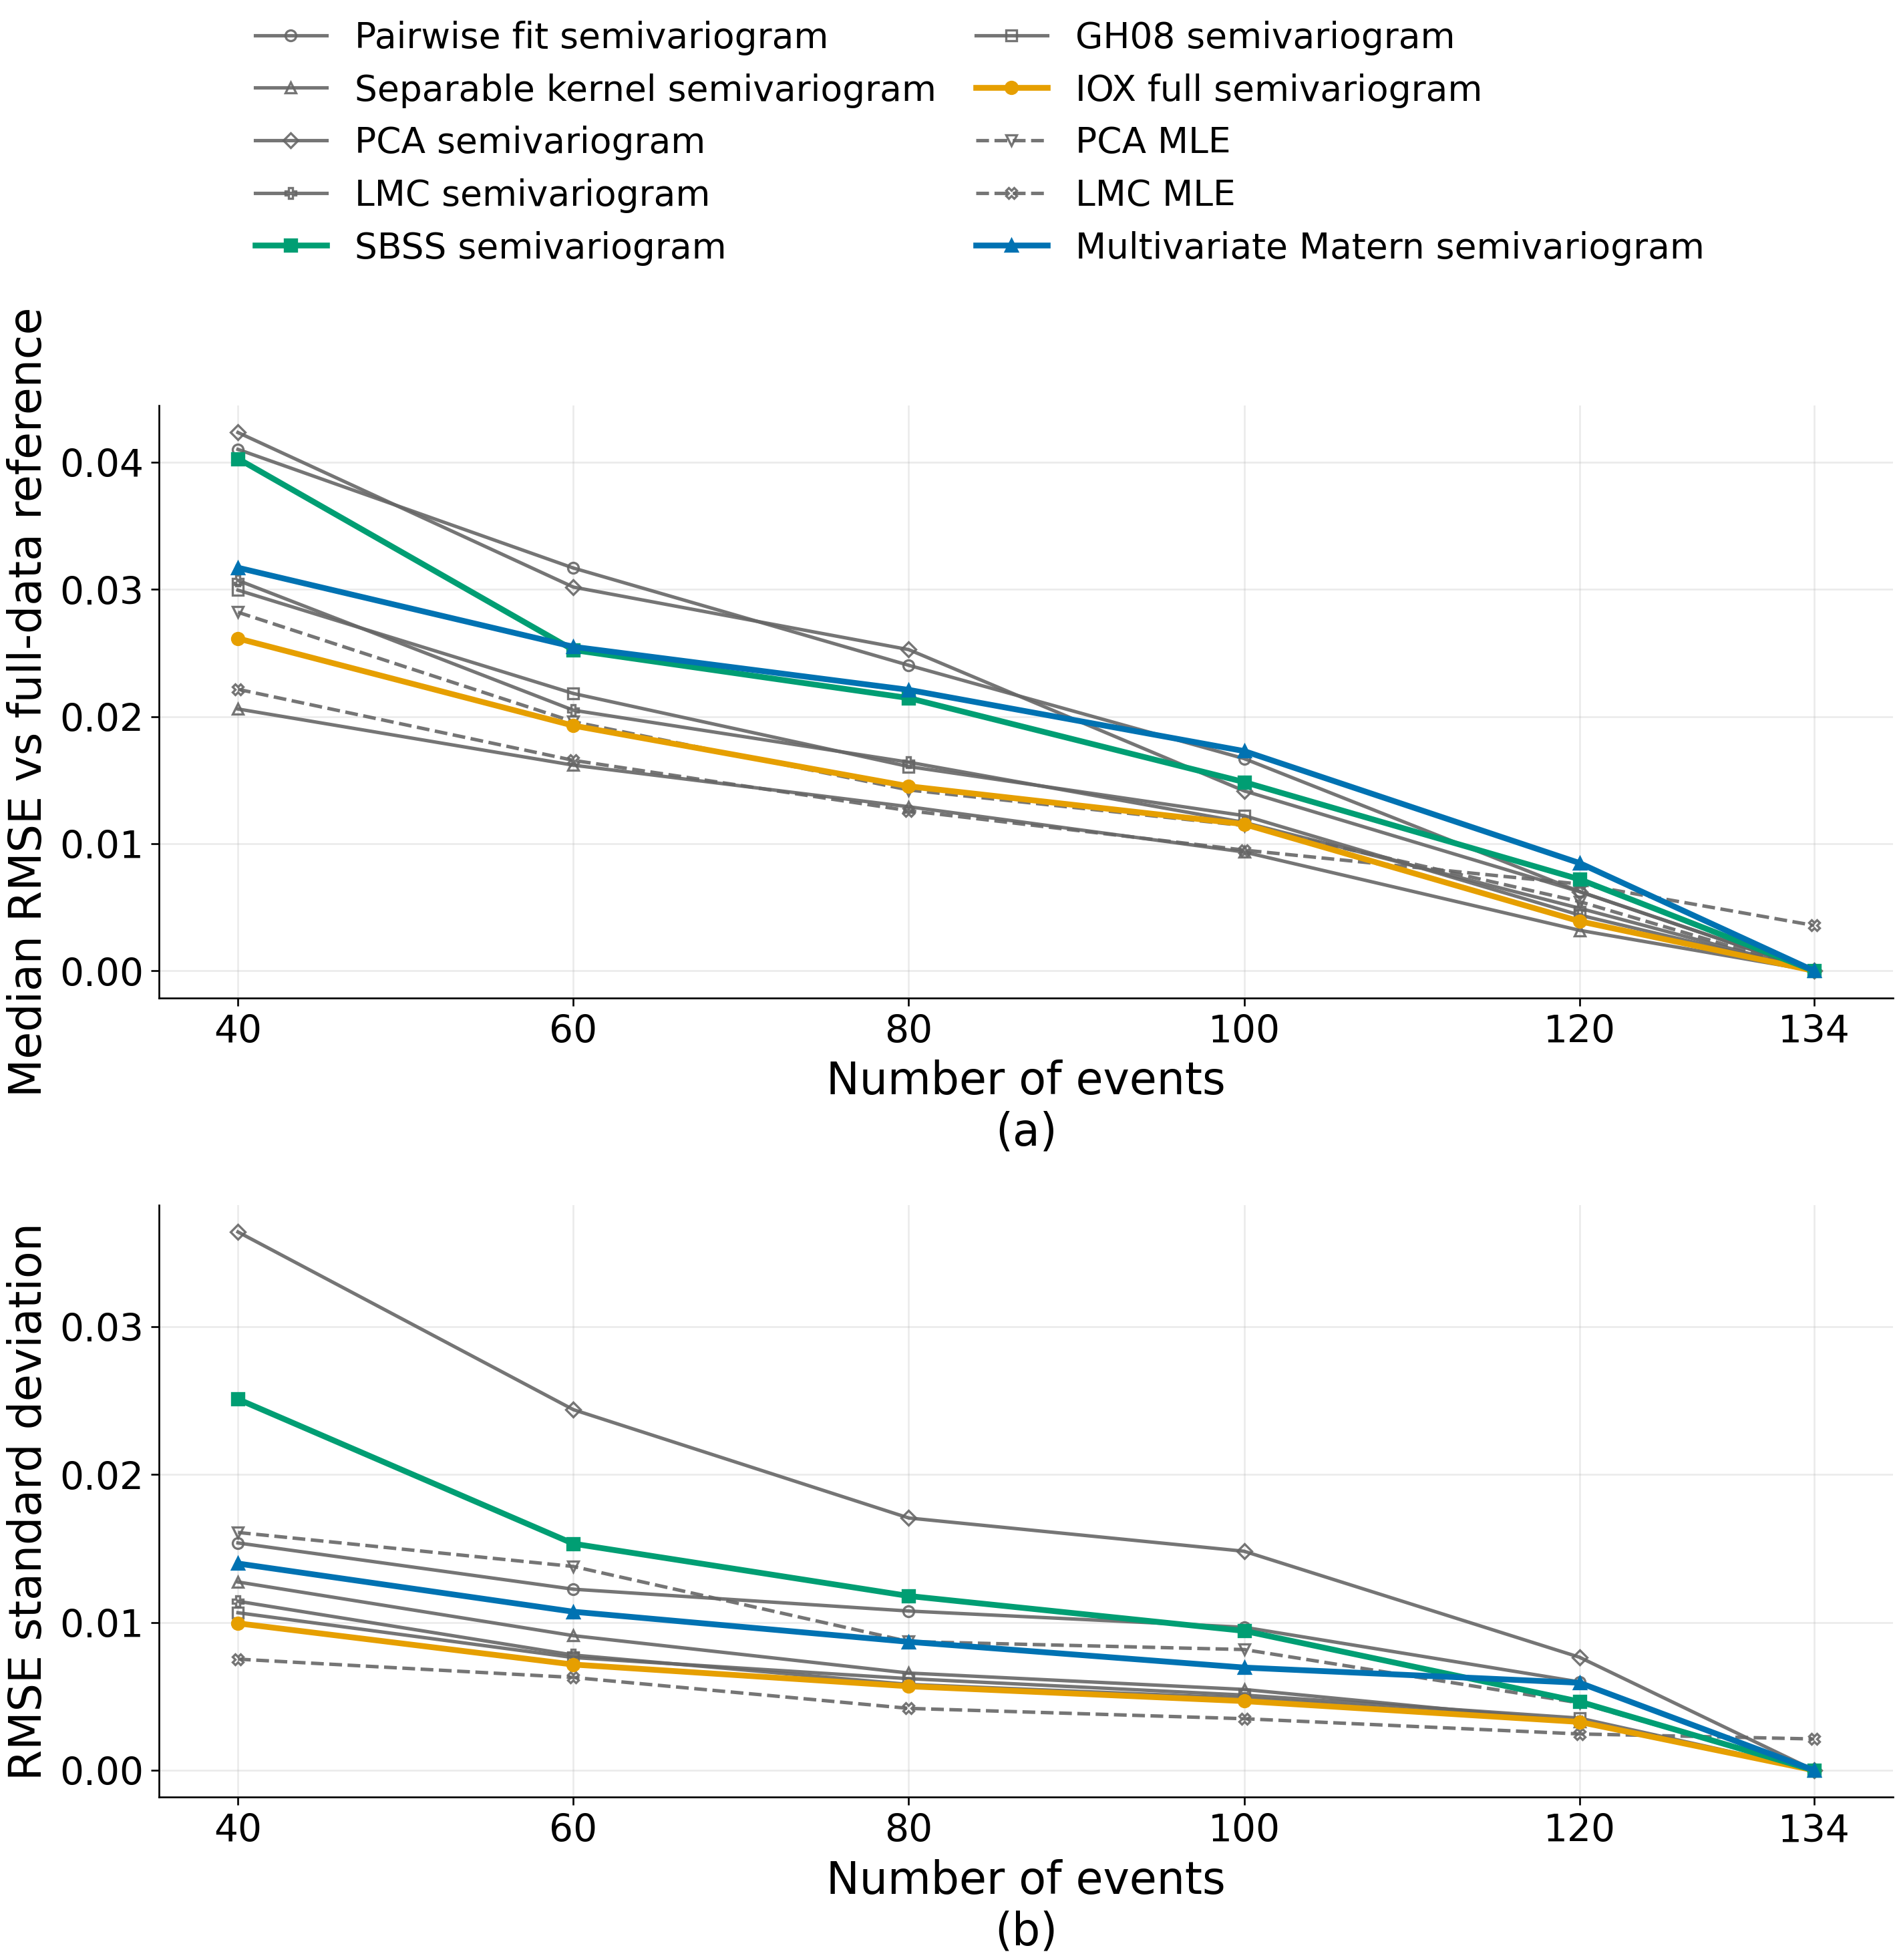

In [4]:
from scripts.analysis.data_requirements.figures import data_requirements
from scripts.common.styles import ALL_MODELS
summary = rerun_summary.copy() if RERUN else recorded_summary.copy()
summary["display_name"] = summary.display_name.replace({"Kronecker semivariogram": "Separable kernel semivariogram"})
methods = list(ALL_MODELS)
display(summary.loc[summary.display_name.isin(methods), ["display_name", "n_events", "n_success", "rmse_median", "rmse_std"]])
fig = data_requirements(summary, methods, False)
fig.savefig(FIGURES / 'figS02_data_requirements.png', dpi=240, bbox_inches="tight", pad_inches=.04)
display(Image(filename=str(FIGURES / 'figS02_data_requirements.png')))
plt.close(fig)